Реализовать фильтр Баттерворда для низкочастотного/высокочастотного фильтра

In [70]:
import os
import math
import torch
from torch.utils.data import Dataset
from torchvision import datasets
import torchvision.transforms as v2
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity, mean_squared_error
import numpy as np
import cv2
import json
import itertools
from scipy.signal import find_peaks

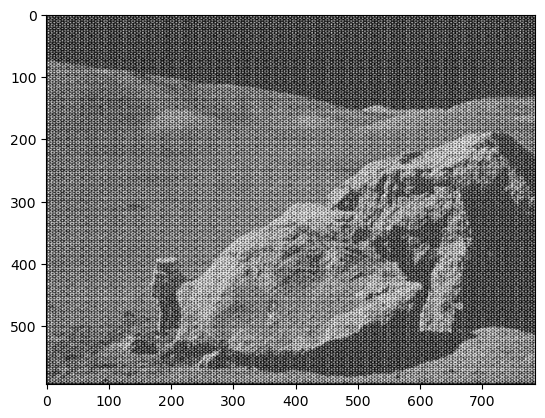

In [71]:
img = cv2.imread('lab3/periodic_noise.JPG', cv2.IMREAD_GRAYSCALE)
img = img[:, :img.shape[1] - 1] # Чтобы ширина нацело делилась на 2
plt.imshow(img, cmap = 'gray')

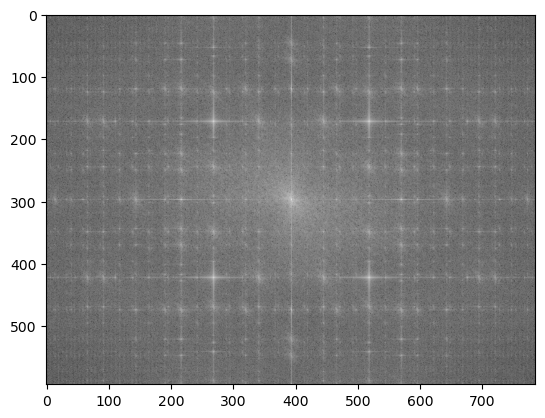

In [72]:
dft = cv2.dft(np.float64(img),flags = cv2.DFT_COMPLEX_OUTPUT)
dft_shift = np.fft.fftshift(dft)

magnitude_spectrum = 20*np.log(cv2.magnitude(dft_shift[:,:,0],dft_shift[:,:,1]))
plt.imshow(magnitude_spectrum, cmap = 'gray')

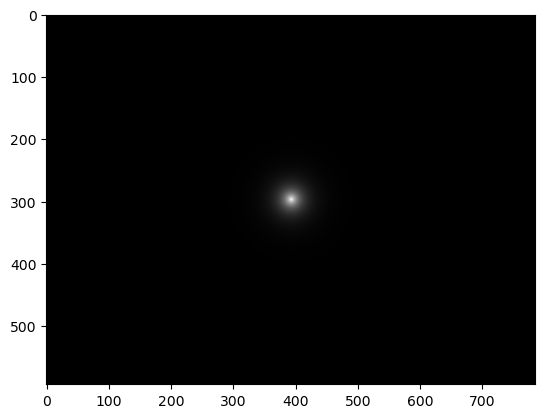

In [82]:
n = 4
mask = np.zeros((img.shape[0], img.shape[1],2), float)
centerX, centerY = (img.shape[1] // 2, img.shape[0] // 2)
offset = 100
x, y = np.meshgrid(np.arange(img.shape[1], dtype=float) - centerX, np.arange(img.shape[0], dtype=float) - centerY)
mask[:, :, 0] = 1 / (1 + np.sqrt(x*x + y*y) / offset) ** (2 * n)
mask[:, :, 1] = 1 / (1 + np.sqrt(x*x + y*y) / offset) ** (2 * n)
plt.imshow(mask[:,:,0], cmap = 'gray')

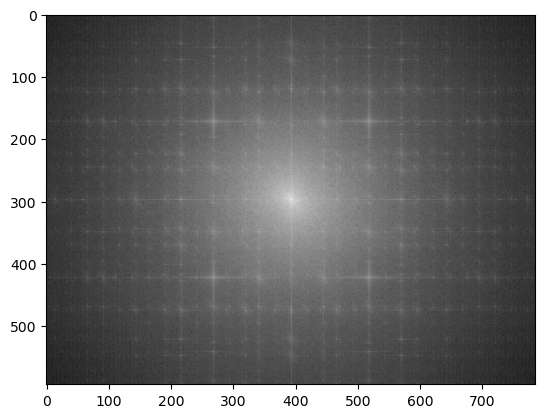

In [83]:
dft_shift_new = dft_shift*mask
filtering_magn_res = 20*np.log(cv2.magnitude(dft_shift_new[:,:,0],dft_shift_new[:,:,1]))
plt.imshow(filtering_magn_res, cmap='gray')

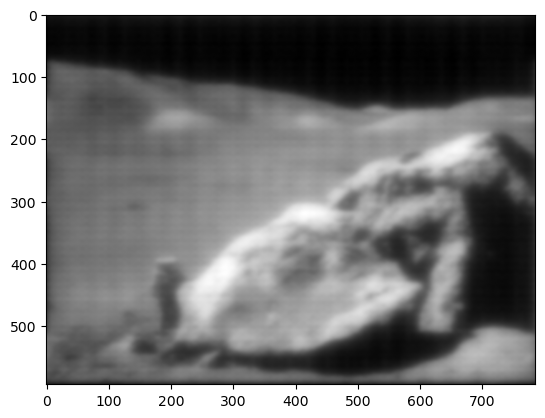

In [84]:
f_ishift = np.fft.ifftshift(dft_shift_new)
img_back = cv2.idft(f_ishift)
img_back = cv2.magnitude(img_back[:,:,0],img_back[:,:,1])
plt.imshow(img_back, cmap = 'gray')